<a href="https://colab.research.google.com/github/lynnkaram/health-informatics-projects/blob/main/final-project-ehr-diabetes-prediction/ehr_diabetes_prediction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# setup code + load data

# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# loading dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "diabetes_binary_health_indicators_BRFSS2015.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "alexteboul/diabetes-health-indicators-dataset",
    file_path
)

df.head()


/tmp/ipython-input-4251021246.py:25: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### The Dataset and EDA
From the Kaggle Dataset "alexteboul/diabetes-health-indicators-dataset", we're loading a version that has binary labels for each row, where 0.0 = no diabetes diagnosis, and 1.0 = diabetes or prediabetes diagnosis. We'll be using this dataset to train a model that estimates the risk of a patient to develop diabetes or prediabetes based on available medical history and lab results (not including diabetes specific tests) and lifestyle data.

Before we start modeling, we examine the data structure and target distribution.

In [ ]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


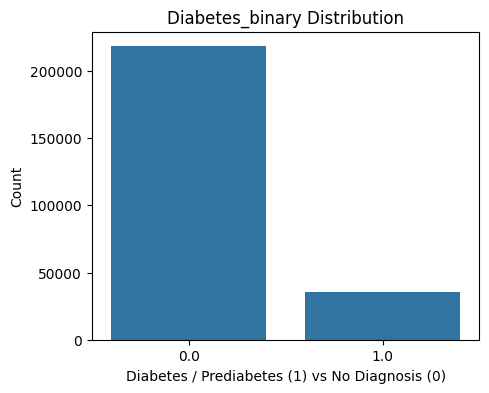

In [ ]:
# check for class imbalances
target_col = "Diabetes_binary"

class_counts = df[target_col].value_counts(normalize=True).rename("proportion")
class_counts

plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title("Diabetes_binary Distribution")
plt.xlabel("Diabetes / Prediabetes (1) vs No Diagnosis (0)")
plt.ylabel("Count")
plt.show()


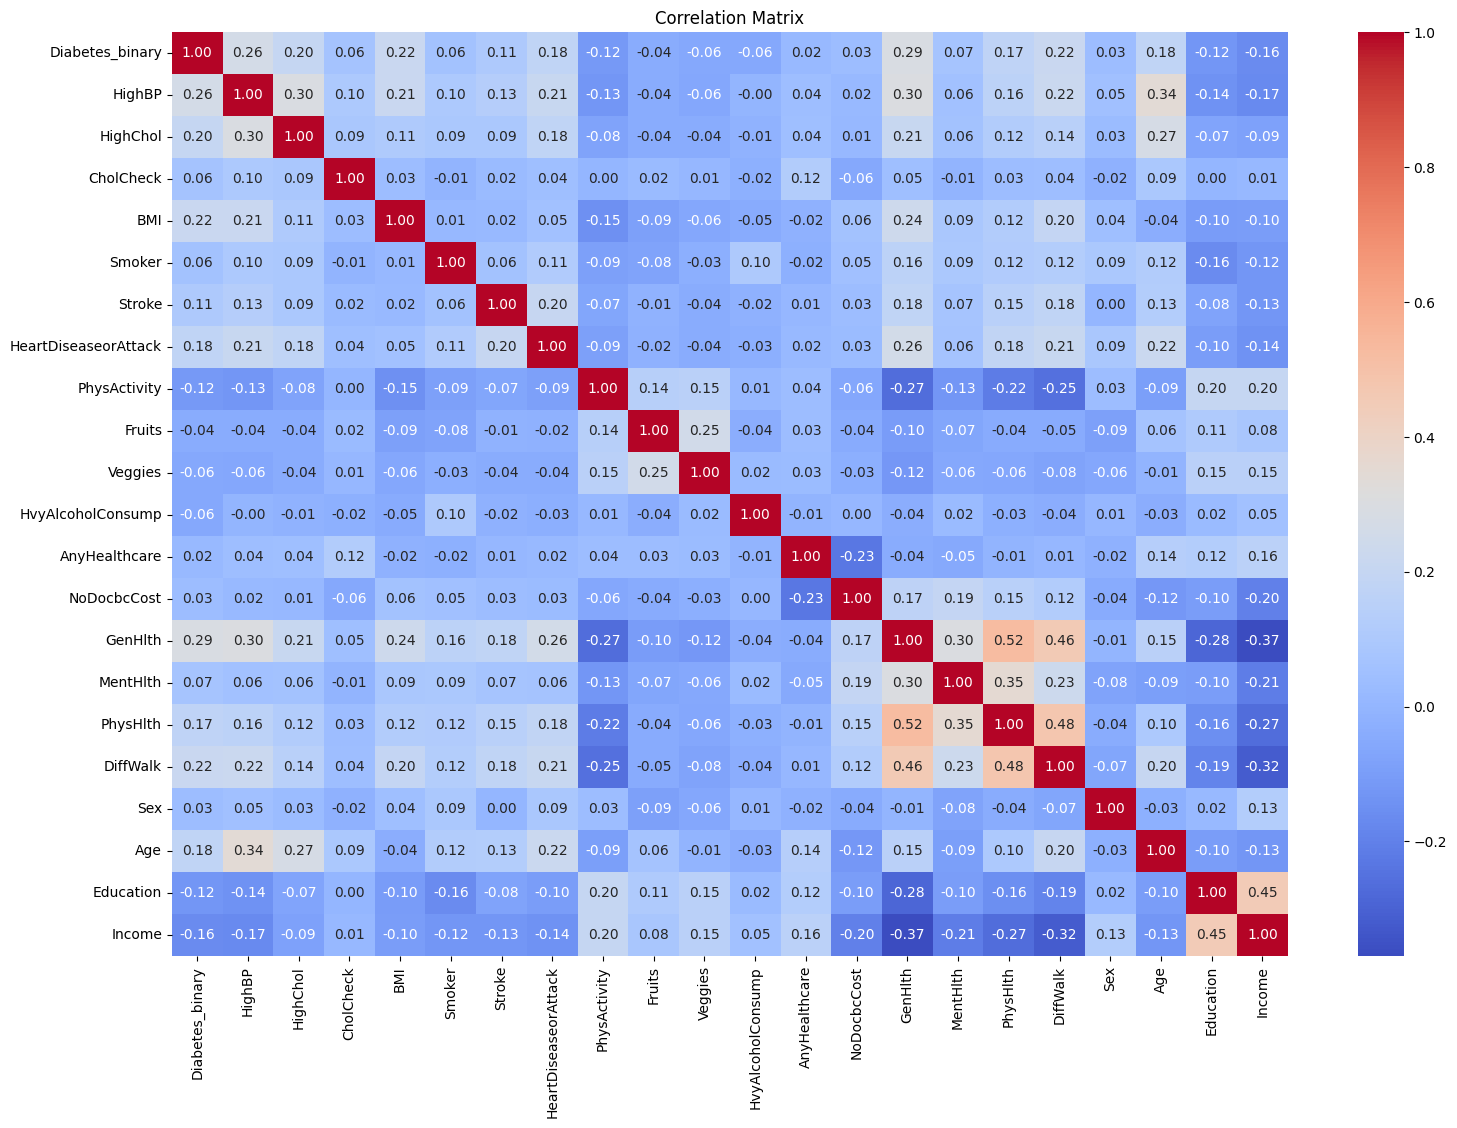

In [ ]:
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(),annot=True,fmt=".2f",  cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

- The dataset has substantial class imbalance, with more individuals reporting no diabetes or prediabetes.
- Many variables have moderate correlations with diabetes status, including **general health, difficulty walking, high blood pressure, BMI, and physical health**. This does align with known clinical risk factors and suggest that both behavioral and health status indicators contribute meaningfully to diabetes risk.


With the basic structure of the data understood, we can now proceed to model building.

We evaluate three approaches (i) Logistic Regression, (ii) Random Forest, and (iii) XGBoost using stratified cross validation to compare their ability to identify individuals at elevated risk.

### Cross-Validation Setup

To evaluate our models fairly, we use stratified 8 fold cross validation. Stratification preserves the original diabetes prevalence within each fold. This is partiularly important here becasue our dataset is imbalanced. Without stratification, some folds could contain too few positive cases, which would make evaluation unstable.

Cross validation also reduces variance in performance estimates by ensuring that every observation appears in both training and validation sets across different folds. This is particularly useful in public health datasets, where heterogeneity across demographic and behavioral subgroups can affect model behavior.

In [ ]:
y = df[target_col]

kf = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
df["fold"] = -1

for fold, (_, val_idx) in enumerate(kf.split(df, y)):
    df.loc[val_idx, "fold"] = fold

df["fold"].value_counts(), df.groupby("fold")[target_col].mean()

(fold
 0    31710
 4    31710
 1    31710
 6    31710
 3    31710
 5    31710
 2    31710
 7    31710
 Name: count, dtype: int64,
 fold
 0    0.139325
 1    0.139325
 2    0.139325
 3    0.139325
 4    0.139325
 5    0.139325
 6    0.139357
 7    0.139357
 Name: Diabetes_binary, dtype: float64)

### Baseline Model Training (LR, RF, XGBoost Default)

To contextualize model performance, we first evaluate two dummy classifiers: a uniform predictor and a "most frequent class" predictor to provide meaningful lower bounds. The most frequent strategy should achieve high apparent accuracy simply by predicting that no patient has diabetes, which mirrors the class imbalance but offers no clinical value.

Before selecting a final model, we train three commonly used algorithms that span different modeling philosophies:

1. **Logistic Regression**: Easily interpretable model widely used in clinical research. It provides a useful baseline and aligns with traditional epidemiologic modeling.

2. **Random Forest**: A non-parametric ensemble of decision trees that better captures nonlinear relationships between symptoms, behaviors, and comorbidities—patterns often present in chronic disease data.

3. **XGBoost**: A gradient boosting model that incrementally corrects its own errors. It often performs well on structured health datasets due to its ability to model complex interactions.

Training all three models across the same 8 folds allows us to compare them directly on accuracy, F1 score, and ROC AUC. This comparison provides justification for which model we ultimately choose to tune and deploy.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_results = {}

for strategy in ["uniform", "most_frequent"]:
    model = DummyClassifier(strategy=strategy)

    accs, precs, recs, f1s, aucs = [], [], [], [], []

    for fold in range(8):
        train_df = df[df["fold"] != fold]
        val_df = df[df["fold"] == fold]

        X_train = train_df.drop(columns=[target_col, "fold"])
        y_train = train_df[target_col]
        X_val = val_df.drop(columns=[target_col, "fold"])
        y_val = val_df[target_col]

        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        prob = model.predict_proba(X_val)[:,1] if hasattr(model, "predict_proba") else np.zeros_like(pred)

        acc = accuracy_score(y_val, pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_val, pred, average="weighted", zero_division=0)
        try:
            auc = roc_auc_score(y_val, prob)
        except:
            auc = 0.5

        accs.append(acc); precs.append(prec); recs.append(rec); f1s.append(f1); aucs.append(auc)

    dummy_results[strategy] = {
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1": np.mean(f1s),
        "ROC AUC": np.mean(aucs)
    }

pd.DataFrame(dummy_results).T

,Accuracy,Precision,Recall,F1,ROC AUC
uniform,0.500560,0.759734,0.500560,0.575323,0.5
most_frequent,0.860667,0.740748,0.860667,0.796217,0.5


In [ ]:
results = {
    "LogisticRegression": [],
    "RandomForest": [],
    "XGBoost_default": []
}

# Class imbalance weight for XGBoost
neg_count = (df[target_col] == 0).sum()
pos_count = (df[target_col] == 1).sum()
scale_weight = neg_count / pos_count

for fold in range(8):
    train_df = df[df["fold"] != fold]
    val_df = df[df["fold"] == fold]

    X_train = train_df.drop(columns=[target_col, "fold"])
    y_train = train_df[target_col]
    X_val = val_df.drop(columns=[target_col, "fold"])
    y_val = val_df[target_col]

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_val)
    lr_prob = lr.predict_proba(X_val)[:, 1]

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_val)
    rf_prob = rf.predict_proba(X_val)[:, 1]

    # XGBoost (default)
    xgb = XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_val)
    xgb_prob = xgb.predict_proba(X_val)[:, 1]

    # Store metrics
    for name, pred, prob in [
        ("LogisticRegression", lr_pred, lr_prob),
        ("RandomForest", rf_pred, rf_prob),
        ("XGBoost_default", xgb_pred, xgb_prob),
    ]:
        acc = accuracy_score(y_val, pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_val, pred, average="weighted"
        )
        auc = roc_auc_score(y_val, prob)

        results[name].append([acc, prec, rec, f1, auc])


In [ ]:
# Convert results into a summary DataFrame
summary_rows = []

for model_name, fold_metrics in results.items():
    metrics_array = np.array(fold_metrics)  # shape: (8 folds, 5 metrics)
    summary_rows.append([
        model_name,
        metrics_array[:, 0].mean(),  # Accuracy
        metrics_array[:, 1].mean(),  # Precision
        metrics_array[:, 2].mean(),  # Recall
        metrics_array[:, 3].mean(),  # F1
        metrics_array[:, 4].mean()   # ROC AUC
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC of ROC"]
)

summary_df


,Model,Accuracy,Precision,Recall,F1,AUC of ROC
0,LogisticRegression,0.863533,0.829787,0.863533,0.829744,0.821958
1,RandomForest,0.859898,0.825358,0.859898,0.830323,0.797361
2,XGBoost_default,0.726746,0.862758,0.726746,0.766551,0.825481


The dummy classifiers demonstrate the limitations of naive strategies: the uniform predictor performs at chance (AUC=0.50), while the "most frequent class" predictor achieves high accuracy but fails to identify any true diabetes cases. If we use these as a baseline, all three trained models provide useful improvements.

Logistic Regression and Random Forest perform similarly, with accuracies around 0.86 and ROC AUC values between 0.79 and 0.82. These results reflect the largely monotonic relationships in BRFSS risk factors and suggest that linear or moderately flexible models already capture much of the signal.

The default XGBoost model shows lower accuracy because it produces fewer positive predictions, but its ROC AUC is highest (0.825), indicating better overall risk discrimination when using predicted probabilities rather than hard class labels. This pattern suggests that XGBoost may be more suitable for risk scoring, provided its hyperparameters are appropriately tuned.

Given these results, the next step is to refine XGBoost through targeted hyperparameter tuning to improve calibration, sensitivity, and overall predictive performance in a screening-oriented setting.

### XGBoost Hyperparameter Tuning

To improve the default XGBoost model, we perform targeted hyperparameter tuning using RandomizedSearchCV. XGBoost has several settings that control tree depth, learning rate, regularization strength, and the fraction of samples or features used in each round. These parameters affect how well the model captures complex interactions without overfitting.

In a clinical setting, tuning is important because small adjustments in model capacity can meaningfully change sensitivity, specificity, and the balance between identifying high risk patients and avoiding excessive false positives. Our goal is to find a configuration that improves discrimination while remaining stable across folds.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

X_full = df.drop(columns=[target_col, "fold"])
y_full = df[target_col]

param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 1, 5],
    "min_child_weight": [1, 3, 5]
}

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_full, y_full)

print("Best parameters found:")
print(xgb_search.best_params_)
print("Best CV ROC AUC:", xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters found:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.7}
Best CV ROC AUC: 0.8308679791654443


In [ ]:
best_params = {
    "subsample": 0.8,
    "n_estimators": 200,
    "min_child_weight": 5,
    "max_depth": 4,
    "learning_rate": 0.1,
    "gamma": 1,
    "colsample_bytree": 0.7
}

tuned_metrics = []

for fold in range(8):
    train_df = df[df["fold"] != fold]
    val_df = df[df["fold"] == fold]

    X_train = train_df.drop(columns=[target_col, "fold"])
    y_train = train_df[target_col]
    X_val = val_df.drop(columns=[target_col, "fold"])
    y_val = val_df[target_col]

    tuned_model = XGBClassifier(
        **best_params,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_weight,
        random_state=42,
        n_jobs=-1
    )

    tuned_model.fit(X_train, y_train)

    pred = tuned_model.predict(X_val)
    prob = tuned_model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_val, pred, average="weighted"
    )
    auc = roc_auc_score(y_val, prob)

    tuned_metrics.append([acc, prec, rec, f1, auc])

tuned_metrics = np.array(tuned_metrics)

print("Average Tuned XGBoost Metrics:")
print(f"Accuracy: {tuned_metrics[:,0].mean():.4f}")
print(f"Precision: {tuned_metrics[:,1].mean():.4f}")
print(f"Recall: {tuned_metrics[:,2].mean():.4f}")
print(f"F1: {tuned_metrics[:,3].mean():.4f}")
print(f"ROC AUC: {tuned_metrics[:,4].mean():.4f}")


Average Tuned XGBoost Metrics:
Accuracy: 0.7214
Precision: 0.8654
Recall: 0.7214
F1: 0.7625
ROC AUC: 0.8308


The tuned XGBoost model achieves an average ROC AUC of 0.8308, matching the strong discrimination observed during cross-validation in the tuning phase. Accuracy and recall remain around 0.72, while precision is substantially higher at 0.87, indicating that when the model predicts elevated diabetes risk, it is usually correct. This pattern reflects XGBoost's tendency to assign higher probabilities only when it is confident, which is appropriate for risk scoring but may lead to missed cases if used with a default 0.5 threshold.

Because diabetes screening prioritizes identifying true positives, the next step is to examine how model performance changes across different probability thresholds. Adjusting the threshold allows us to balance sensitivity and specificity in a way that aligns with screening goals, resource availability, and acceptable levels of follow-up testing.

### Threshold Analysis (Sensitivity vs Specificity Tradeoffs)

ML classifiers output probabilities, not just class labels.
The default 0.5 threshold does not always align with clinical priorities.

For diabetes screening, higher sensitivity is often preferred to avoid missing individuals who may require diagnostic testing or counseling.

Here we evaluate how performance changes at several practical probability thresholds.

In [ ]:
final_xgb = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)

X_full = df.drop(columns=[target_col, "fold"])
y_full = df[target_col]

final_xgb.fit(X_full, y_full)

y_prob = final_xgb.predict_proba(X_full)[:, 1]


In [ ]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_full, y_pred_t).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    threshold_results.append([t, sensitivity, specificity, precision])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Sensitivity", "Specificity", "Precision"]
)

display(threshold_df)


,Threshold,Sensitivity,Specificity,Precision
0,0.2,0.965343,0.422367,0.212940
1,0.3,0.929638,0.529505,0.242352
2,0.4,0.879025,0.622432,0.273730
3,0.5,0.804221,0.710641,0.310317
4,0.6,0.698184,0.795552,0.356022
5,0.7,0.547276,0.876620,0.417959


Lower thresholds (0.2 - 0.3) maximize sensitivity but produce many false positives. Higher thresholds (0.6 - 0.7) improve specificity but miss a large number of true diabetes cases. Thresholds around 0.4 - 0.5 offer a more balanced tradeoff, with high sensitivity and moderate specificity. In the context of screening for diabetes, a threshold of 0.4 is a reasonable choice.

### Final Model


Selected Threshold: 0.4
Sensitivity: 0.879
Specificity: 0.622
Precision: 0.274
F1 Score: 0.417
TN: 135898 FP: 82436 FN: 4276 TP: 31070


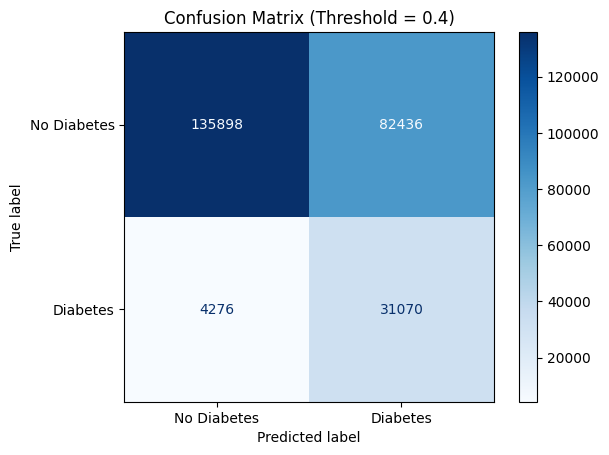

In [ ]:
selected_threshold = 0.4
y_pred_selected = (y_prob >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_full, y_pred_selected).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print("Selected Threshold:", selected_threshold)
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("Precision:", round(precision, 3))
print("F1 Score:", round(f1, 3))
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

ConfusionMatrixDisplay.from_predictions(
    y_full,
    y_pred_selected,
    display_labels=["No Diabetes", "Diabetes"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix (Threshold = {selected_threshold})")
plt.show()


### Bias Checks

We check the average predicted diabetes risk across basic demographic groups. This helps identify whether the model systematically assigns higher or lower risk scores to certain groups.

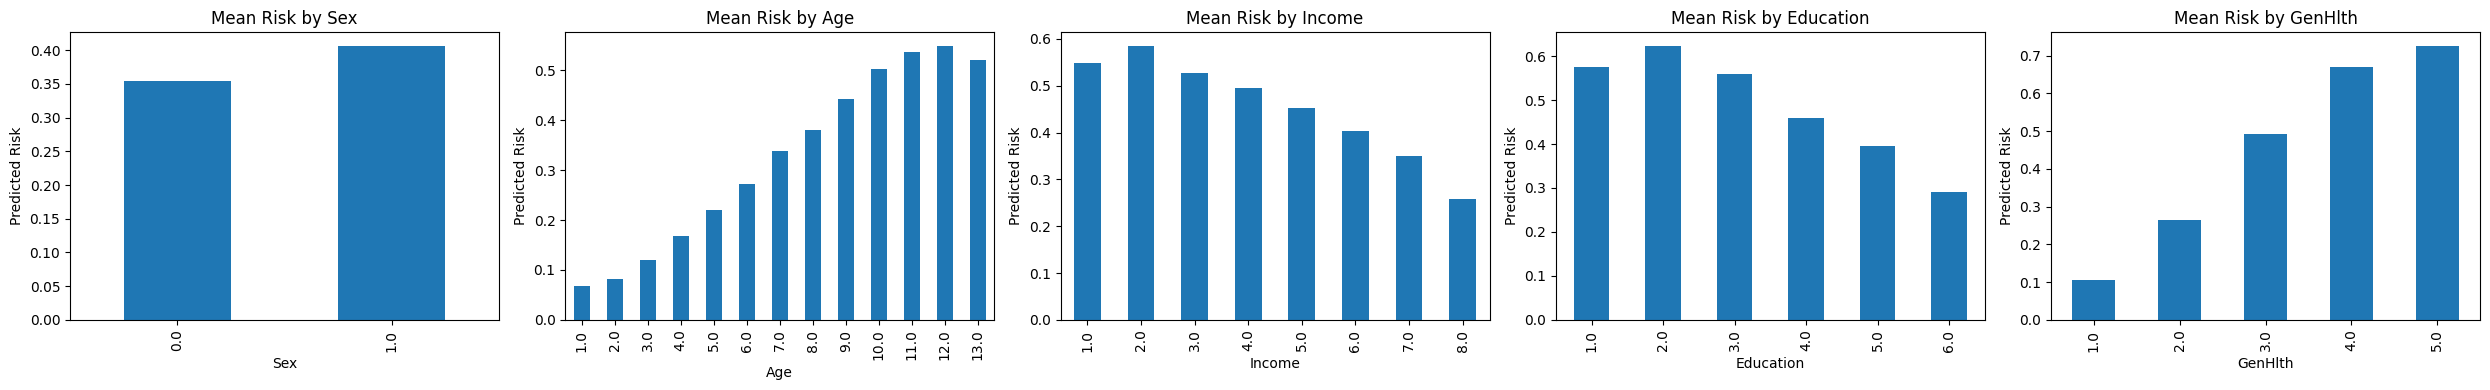

In [ ]:
df["predicted_risk"] = y_prob

subgroups = ["Sex", "Age", "Income", "Education", "GenHlth"]

n = len(subgroups)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)

for i, col in enumerate(subgroups):
    ax = axes[0][i]
    means = df.groupby(col)["predicted_risk"].mean()

    means.plot(kind="bar", ax=ax)
    ax.set_title(f"Mean Risk by {col}")
    ax.set_ylabel("Predicted Risk")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()



Mean predicted risk varies in expected directions across demographic and health categories. Also, subgroup patterns are clinically consistent.

For example, predicted risk increases with age, worsened general health, and lower income or education levels. These patterns match known population trends in diabetes risk and do not indicate unexpected or extreme disparities.

The model is learning meaningful relationships from the underlying BRFSS data rather than random noise.
